In [16]:
import numpy as np
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import scipy

In [17]:
dataset = np.loadtxt('../trainData.txt', delimiter=',')
D=dataset[:,:6].T
L=dataset[:,6]

labels={
    1:"True",
    0:"False"
}

D,L

(array([[ 1.85284048, -0.21530775,  0.04653456, ..., -0.06393955,
          1.06665359, -0.47186462],
        [-0.16436898,  1.63665974, -1.16487257, ..., -0.92205024,
          3.27717415, -0.37118987],
        [ 1.09839078, -0.61831145,  0.04392191, ...,  1.65445602,
         -0.53087884, -1.04041218],
        [-0.93073689,  0.99002204, -0.41369086, ..., -1.527528  ,
          1.42338924, -0.253746  ],
        [-1.0193342 ,  0.38670252, -1.08847926, ...,  1.87609599,
         -1.11381038, -0.02120134],
        [ 1.16696309,  1.15926273, -1.37988988, ...,  0.75929015,
         -0.15047129, -1.4376229 ]], shape=(6, 6000)),
 array([1., 0., 1., ..., 1., 0., 0.], shape=(6000,)))

In [18]:
def logpdf_GAU_ND(x, mu, C):
    M=x.shape[0]
    XC = x - mu
    sign, logdet = np.linalg.slogdet(C)
    invC = np.linalg.inv(C)
    quad = np.sum(XC * (invC @ XC), axis=0)
    return -0.5 * (M * np.log(2*np.pi) + logdet + quad)

def loglikelihood(XND, m_ML, C_ML):
    logpdf=logpdf_GAU_ND(XND,m_ML,C_ML)
    return np.sum(logpdf)

In [19]:
def getMu(D):
    return D.sum(axis=1)/D.shape[1]

def vRow(vet):
    return vet.reshape((1, vet.size))
def vCol(vet):
     return vet.reshape((vet.size, 1))

def getC(D):
    mu=getMu(D)
    mu=vCol(mu)
    Dc=D-mu
    return (Dc @ Dc.T)/Dc.shape[1]

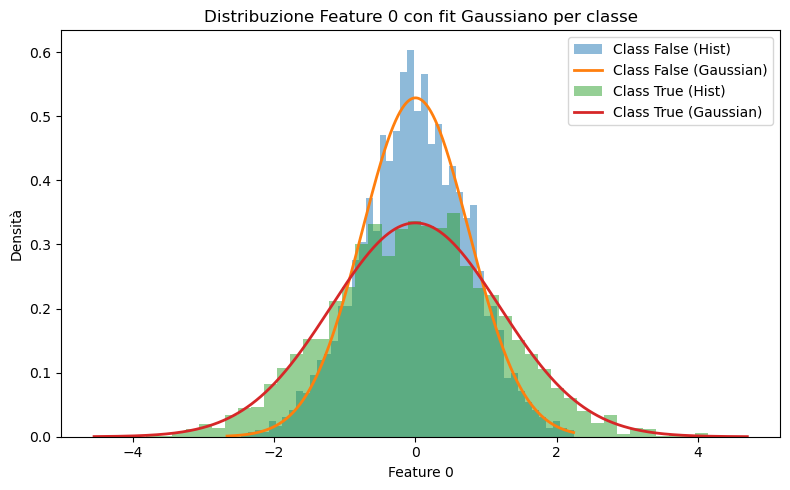

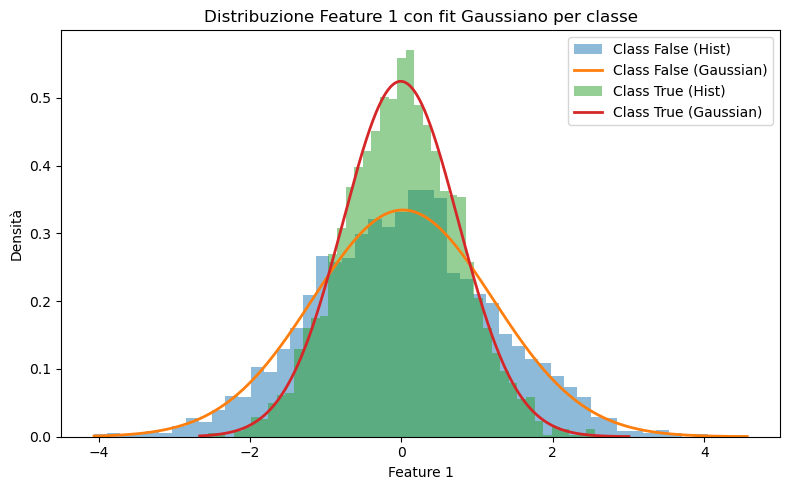

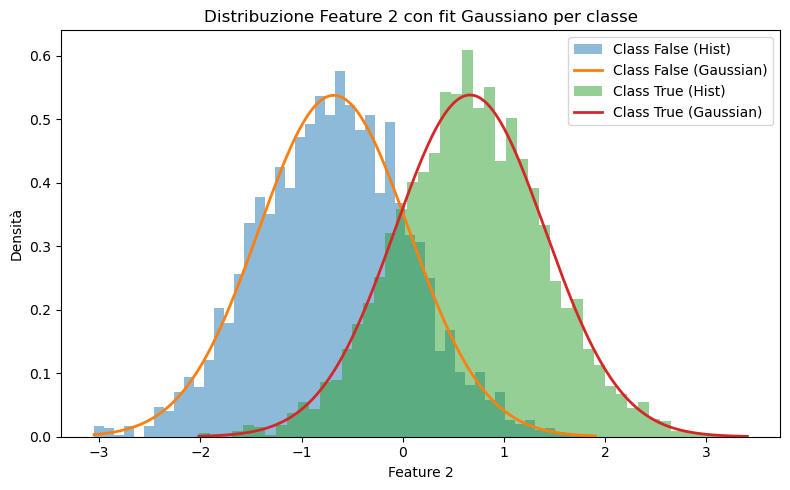

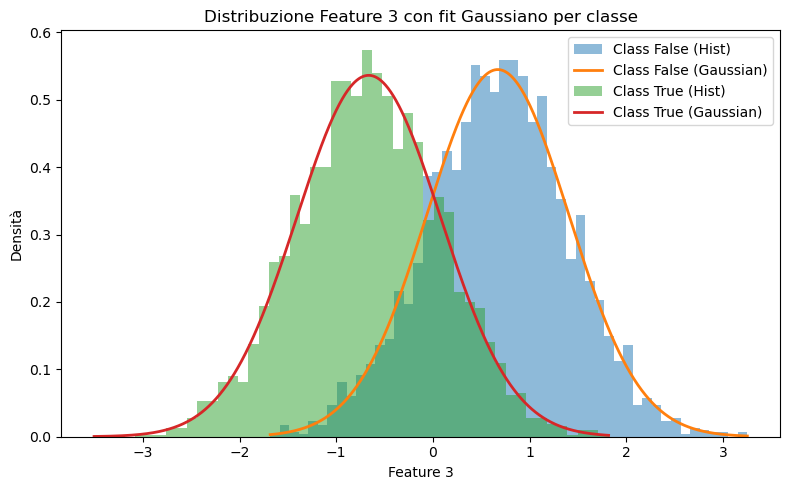

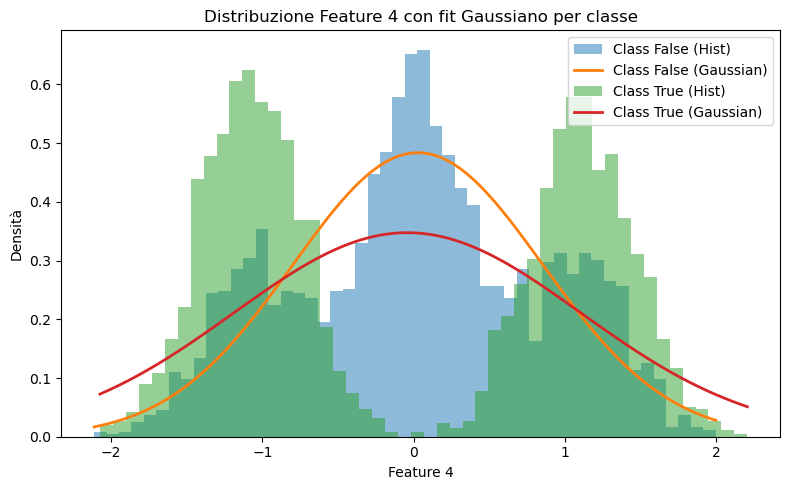

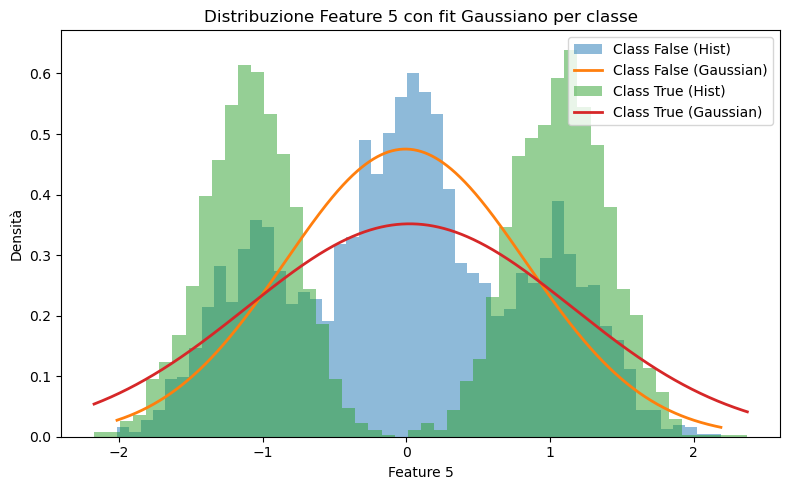

In [21]:
n_features = D.shape[0]
for i in range(n_features):
    plt.figure(figsize=(8, 5))

    for cnt in range(2):
        mask = L == cnt
        D0 = vRow(D[i, mask])
        mu = getMu(D0)
        C = getC(D0)

        # 1. Disegna l'istogramma
        plt.hist(D0.ravel(), bins=50, density=True, alpha=0.5, label=f'Class {labels[cnt]} (Hist)')

        # 2. Crea un asse X ordinato che va dal minimo al massimo dei tuoi dati per disegnare la curva
        XPlot = np.linspace(D0.min(), D0.max(), 1000)

        # 3. Calcola la log-densità su XPlot (ricorda di usare vRow) ed esponenziala
        pdf_values = np.exp(logpdf_GAU_ND(vRow(XPlot), mu, C))

        # 4. Disegna la curva Gaussiana
        plt.plot(XPlot.ravel(), pdf_values.ravel(), linewidth=2, label=f'Class {labels[cnt]} (Gaussian)')

    plt.title(f'Distribuzione Feature {i} con fit Gaussiano per classe')
    plt.xlabel(f'Feature {i}')
    plt.ylabel('Densità')
    plt.legend()
    plt.tight_layout()
    plt.show()